# VQCFD Results Analysis

The reusable logic lives in `analysis.py`. This notebook only contains run selections and plotting options.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis as an

an.configure_plots()
RESULTS_ROOT = an.RESULTS_ROOT
RESULTS_ROOT


PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results')

## Discover saved runs


In [2]:
runs = an.list_runs()
an.print_runs(runs)


N2_L1              mode=noise_free   N=2   L=1   circuit=default    params=True variance=False
N2_L2              mode=noise_free   N=2   L=2   circuit=default    params=True variance=False
N2_L3              mode=noise_free   N=2   L=3   circuit=default    params=True variance=False
N2_L4              mode=noise_free   N=2   L=4   circuit=default    params=True variance=False
N2_L5              mode=noise_free   N=2   L=5   circuit=default    params=True variance=False
N2_L6              mode=noise_free   N=2   L=6   circuit=default    params=True variance=False
N2_L7              mode=noise_free   N=2   L=7   circuit=default    params=True variance=False
N2_L8              mode=noise_free   N=2   L=8   circuit=default    params=True variance=False
N3_L1              mode=noise_free   N=3   L=1   circuit=default    params=True variance=False
N3_L2              mode=noise_free   N=3   L=2   circuit=default    params=True variance=False
N3_L3              mode=noise_free   N=3   L=3   c

In [20]:
# Optional filters: n=..., l=...
preset_rows = an.list_initial_param_presets(l=1, show_variants=False)


N=2, L=1 | default_len=5 | default_mse=2.299774959702107e-14
N=3, L=1 | default_len=7 | default_mse=0.017278574634361943
N=4, L=1 | default_len=9 | default_mse=0.026448571369803636
N=5, L=1 | default_len=11 | default_mse=0.026839737986057908
N=6, L=1 | default_len=13 | default_mse=0.026308669655778574
N=7, L=1 | default_len=15 | default_mse=0.025868179172688327
N=8, L=1 | default_len=17 | default_mse=0.0255992629189411
N=9, L=1 | default_len=19 | default_mse=0.025467634556539696
N=10, L=1 | default_len=21 | default_mse=0.025382174331034273
count=9 presets


## Inspect one run


In [21]:
DIR_LABEL = "N3"
LABEL = "L3"

run = an.load_run(DIR_LABEL, LABEL)
run


RunData(dir_label='N3', label='L3', full_label='N3_L3', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N3'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N3/data_L3'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N3/figures_L3'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': True, 'data_dir': 'results/results_N3/data_L3', 'dir_label': 'N3', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 100000, 'fig_dir': 'results/results_N3/figures_L3', 'grad_tol': 0.001, 'init_param_random_center': 2.891592653589793, 'init_param_random_scale': 0.1, 'initial_params': None, 'initial_params_presets_file': 'initial_params_presets.yaml', 'initial_params_variant': None, 'l': 3, 'label': 'L3', 'manifest_path': 'results/results_N3/manifest_N3_L3.yaml', 'max_iter': 100, 'mode': 'noise_free', 'mu': 0.01, 'n': 3, 'n_timesteps': 28, 'n_total': 8, 'optimization_steps': 1000, 'pat

In [22]:
print("manifest path:", run.files["manifest"])
print("values yaml path:", run.files["values_yaml"])
print("values keys:", list(run.values.keys()))
run.values


manifest path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N3/manifest_N3_L3.yaml
values yaml path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N3/data_L3/values_N3_L3.yaml
values keys: ['n', 'l', 'shots', 'max_iter', 't_total', 'mu', 'dt', 'plat_tol', 'patience', 'initial_params_source', 'expressibility', 'entangling_capability', 'initial_fit_mse', 'shots_used_per_timestep', 'shots_used_total']


{'n': 3,
 'l': 3,
 'shots': 100,
 'max_iter': 100,
 't_total': 0.29,
 'mu': 0.01,
 'dt': 0.01,
 'plat_tol': 0.00015,
 'patience': 15,
 'initial_params_source': 'preset',
 'expressibility': 0.16018213706575626,
 'entangling_capability': 0.5584908245230931,
 'initial_fit_mse': 2.724906430778326e-11,
 'shots_used_per_timestep': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'shots_used_total': 0}

In [23]:
costs = run.costs
times = run.times
params = run.params
variance = run.variance

print("costs:", None if costs is None else costs.shape)
print("times:", None if times is None else times.shape)
print("params:", None if params is None else params.shape)
print("variance:", variance)


costs: (28,)
times: (28,)
params: (29, 13)
variance: None


In [24]:
cost_histories = an.load_per_timestep_histories(run, "cost_iter")
param_histories = an.load_per_timestep_histories(run, "params_iter")
print("cost_iter timesteps:", len(cost_histories))
print("params_iter timesteps:", len(param_histories))


cost_iter timesteps: 28
params_iter timesteps: 0


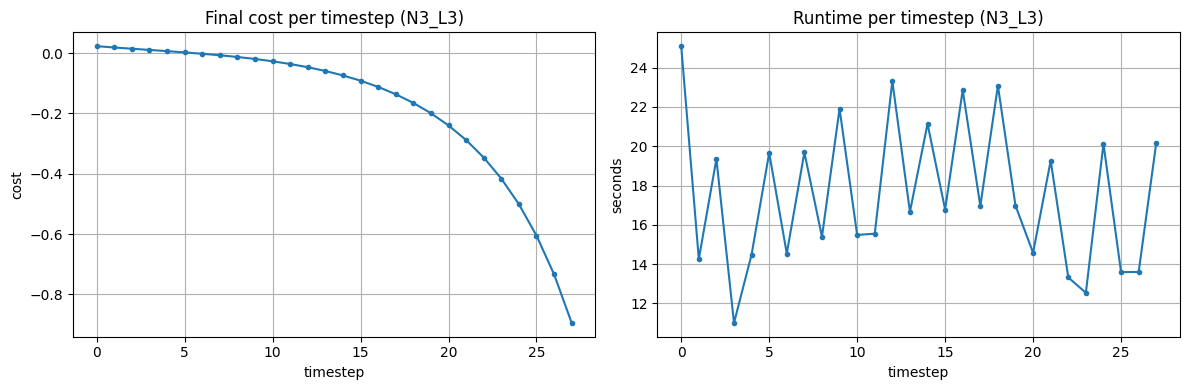

In [25]:
an.plot_costs_and_times(run);


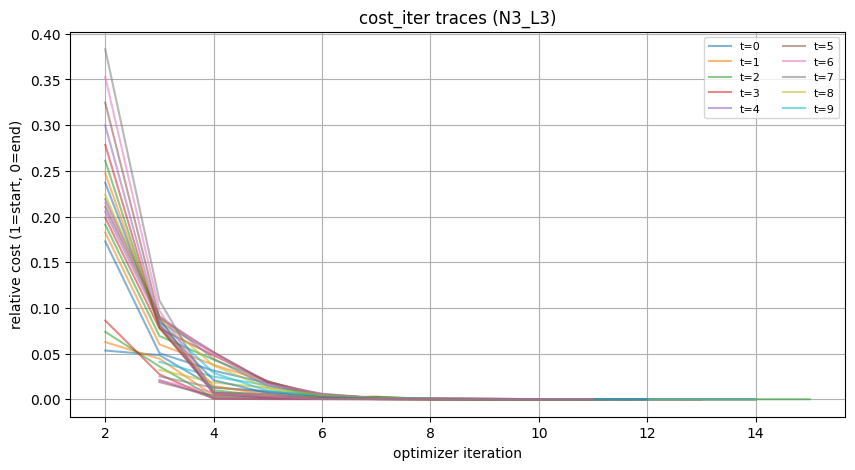

In [26]:
an.plot_cost_histories(
    run,
    normalize=True,
    remove_outliers=True,
    outlier_method="iqr",       # "iqr" or "percentile"
    outlier_factor=3.0,
    outlier_percentiles=(1.0, 99.0),
    show_first_n_labels=10,
);


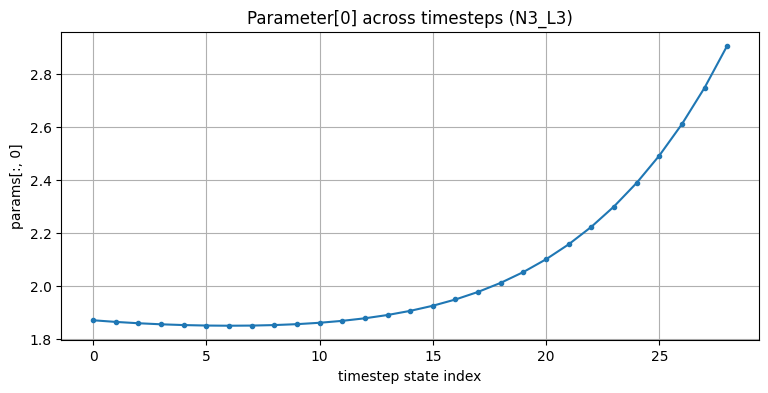

In [27]:
an.plot_parameter_history(run, parameter_index=0);


shots_used_total: 0


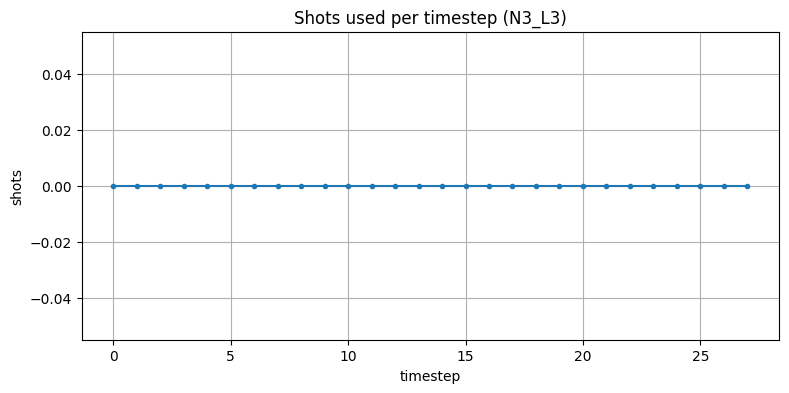

In [28]:
an.plot_shots(run);


## Classical and quantum fields at one timestep

Use `TIMESTEP = 0` for the initial state, a positive saved-state index, or `-1` for the final state. The plot reports MSE, R², and normalized squared-overlap fidelity.


timestep    28.000000
time         0.280000
MSE          0.000519
R2           0.999505
Fidelity     0.999515
dtype: float64

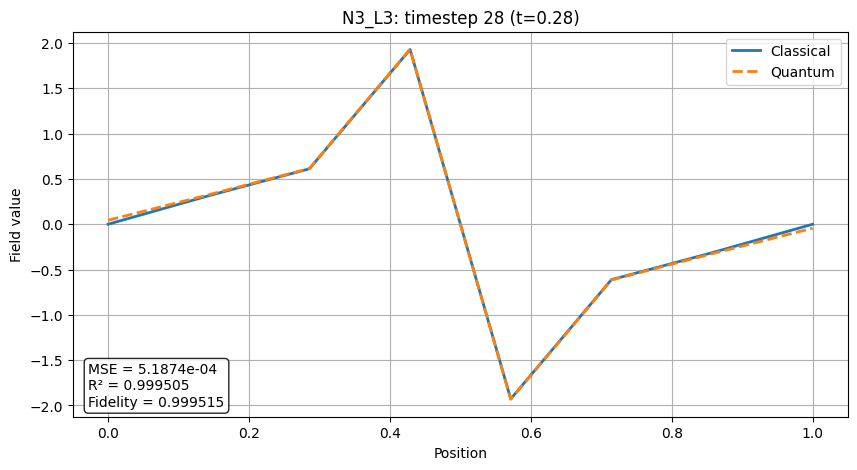

In [29]:
TIMESTEP = -1

timestep_comparison, ax = an.plot_run_timestep_comparison(run, timestep=TIMESTEP)
pd.Series({key: timestep_comparison[key] for key in ["timestep", "time", "MSE", "R2", "Fidelity"]})


## Expressibility and entangling capability


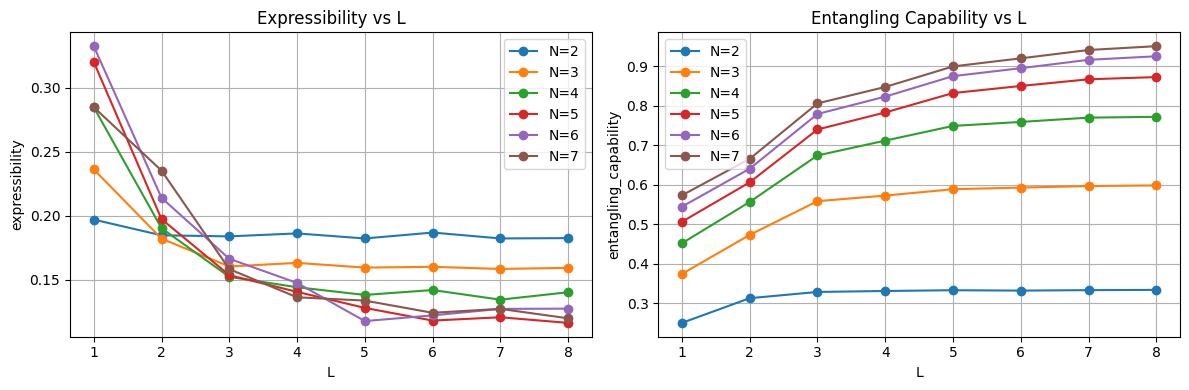

In [3]:
# Add (dir_label, label) pairs here. With an empty selection, use all runs that contain either metric.
EXPR_ENTCAP_SELECTION = []

if EXPR_ENTCAP_SELECTION:
    expr_runs = an.load_runs(EXPR_ENTCAP_SELECTION)
else:
    expr_runs = [
        an.load_run(row["dir_label"], row["label"])
        for row in runs
        if an.load_run(row["dir_label"], row["label"]).metadata("expressibility") is not None
        or an.load_run(row["dir_label"], row["label"]).metadata("entangling_capability") is not None
    ]

if expr_runs:
    an.plot_expr_entcap_vs_l(expr_runs, n_filter=None)
else:
    print("No selected runs contain expressibility or entangling-capability values.")


## Configurable multi-run comparison table

The table contains N, L, variance, expressibility, entangling capability, circuit, and final-state R²/fidelity/MSE. Variance-only runs can be supplied separately and are matched to simulation runs by `(N, L, Circuit)`. Leave `RUN_SELECTION` empty to select every available non-variance run with saved parameters.

Older manifests do not record a circuit name, so they are shown as `default`. Use `CIRCUIT_OVERRIDES` for older runs whose circuit is known from their label or experiment notes.


In [4]:
RUN_SELECTION = [
    # ("N3", "L2"),
    # ("N4", "L3"),
]

# Optional explicit variance selection. Leave empty to use all discovered variance runs.
VARIANCE_SELECTION = []

# Example: {"experiment_uni2_N4L3": "uni2"}
CIRCUIT_OVERRIDES = {}

selected_runs = an.load_runs(RUN_SELECTION) if RUN_SELECTION else an.discover_simulation_runs()
variance_runs = (
    [an.load_variance_run(d, label) for d, label in VARIANCE_SELECTION]
    if VARIANCE_SELECTION
    else an.discover_variance_runs()
)

run_table = an.build_run_table(
    selected_runs,
    variance_runs=variance_runs,
    circuit_overrides=CIRCUIT_OVERRIDES,
)
run_table


/Users/joel/Documents/MA/Code/VQCFD_quimb/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Run,N,L,Var,Expressibility,EntanglingCapability,Circuit,R2,Fidelity,MSE
0,N2_L1,2,1,0.317165,0.196844,0.250619,default,0.999700,9.997293e-01,2.261700e-04
1,N2_L2,2,2,0.296537,0.184564,0.313082,default,0.999701,9.997301e-01,2.255952e-04
2,N2_L3,2,3,NaN,0.183727,0.328842,default,0.999701,9.997303e-01,2.255602e-04
3,N2_L4,2,4,0.279786,0.186045,0.331312,default,0.999700,9.997295e-01,2.260133e-04
4,N2_L5,2,5,NaN,0.182096,0.333216,default,0.999700,9.997292e-01,2.262221e-04
5,N2_L6,2,6,NaN,0.186717,0.332239,default,0.999700,9.997292e-01,2.262778e-04
6,N2_L7,2,7,NaN,0.182113,0.333437,default,0.999701,9.997298e-01,2.258642e-04
7,N2_L8,2,8,0.270733,0.182373,0.334074,default,0.999698,9.997280e-01,2.275218e-04
8,N3_L1,3,1,0.144278,0.236094,0.374424,default,0.755790,8.054560e-01,2.560467e-01
9,N3_L2,3,2,0.138905,0.181958,0.473112,default,0.999505,9.995154e-01,5.188304e-04


,Run,N,L,Var,Expressibility,EntanglingCapability,Circuit,R2,Fidelity,MSE
0,N2_L1,2,1,0.317165,0.196844,0.250619,default,0.999700,0.999729,0.000226
1,N2_L2,2,2,0.296537,0.184564,0.313082,default,0.999701,0.999730,0.000226
2,N2_L3,2,3,NaN,0.183727,0.328842,default,0.999701,0.999730,0.000226
3,N2_L4,2,4,0.279786,0.186045,0.331312,default,0.999700,0.999730,0.000226
4,N2_L5,2,5,NaN,0.182096,0.333216,default,0.999700,0.999729,0.000226
5,N2_L6,2,6,NaN,0.186717,0.332239,default,0.999700,0.999729,0.000226
6,N2_L7,2,7,NaN,0.182113,0.333437,default,0.999701,0.999730,0.000226
7,N2_L8,2,8,0.270733,0.182373,0.334074,default,0.999698,0.999728,0.000228
8,N3_L1,3,1,0.144278,0.236094,0.374424,default,0.755790,0.805456,0.256047
9,N3_L2,3,2,0.138905,0.181958,0.473112,default,0.999505,0.999515,0.000519


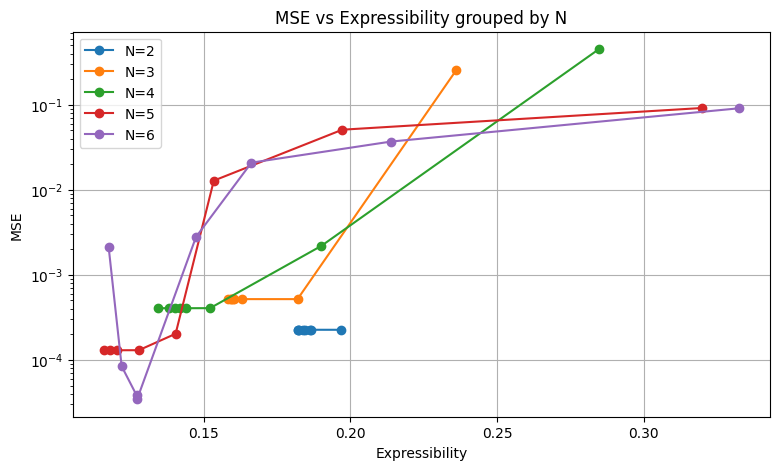

In [42]:
# Any columns in an.RUN_TABLE_COLUMNS can be used for X, Y, or GROUP_BY.
X = "Expressibility"
Y = "MSE"
GROUP_BY = "N"          # "N", "L", "Circuit", another column, or None

NS = [2,3,4,5,6] # None               # e.g. [3, 4, 5]
LS = None               # e.g. [1, 2, 3]
CIRCUITS = None         # e.g. ["default", "uni2"]

filtered_table, ax = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    ns=NS,
    ls=LS,
    circuits=CIRCUITS,
    group_by=GROUP_BY,
    kind="line",        # "line" or "scatter"
    log_y=True,
)
filtered_table
